In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns


import warnings
warnings.filterwarnings("ignore")

In [2]:
df= pd.read_csv("diabetes.csv")

In [3]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


In [7]:
zero_valued_features= ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

for col in zero_valued_features:
    zero_count= (df[col]==0).sum()
    print(f" {col}: {zero_count}")

 Glucose: 5
 BloodPressure: 35
 SkinThickness: 227
 Insulin: 374
 BMI: 11


In [8]:
df[zero_valued_features] = df[zero_valued_features].replace(0, np.nan)

In [9]:
missing_value_features = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

* Visualizing that the missing observations in SkinThickness and Insulin frequently occur together within the same samples.

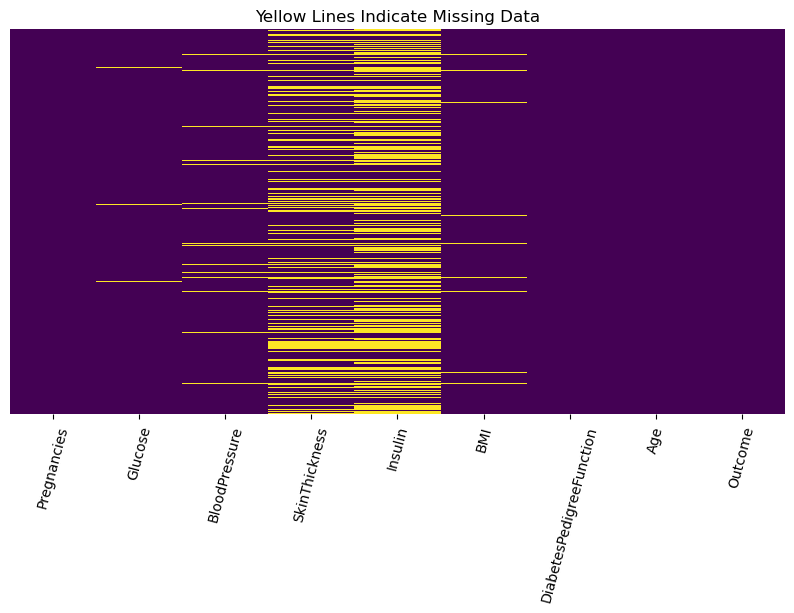

In [10]:
plt.figure(figsize=(10, 5))
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title("Yellow Lines Indicate Missing Data")
plt.xticks(rotation=75)
plt.show()

* To visualize the distribution of each variable in the dataset according to the Outcome classes. 

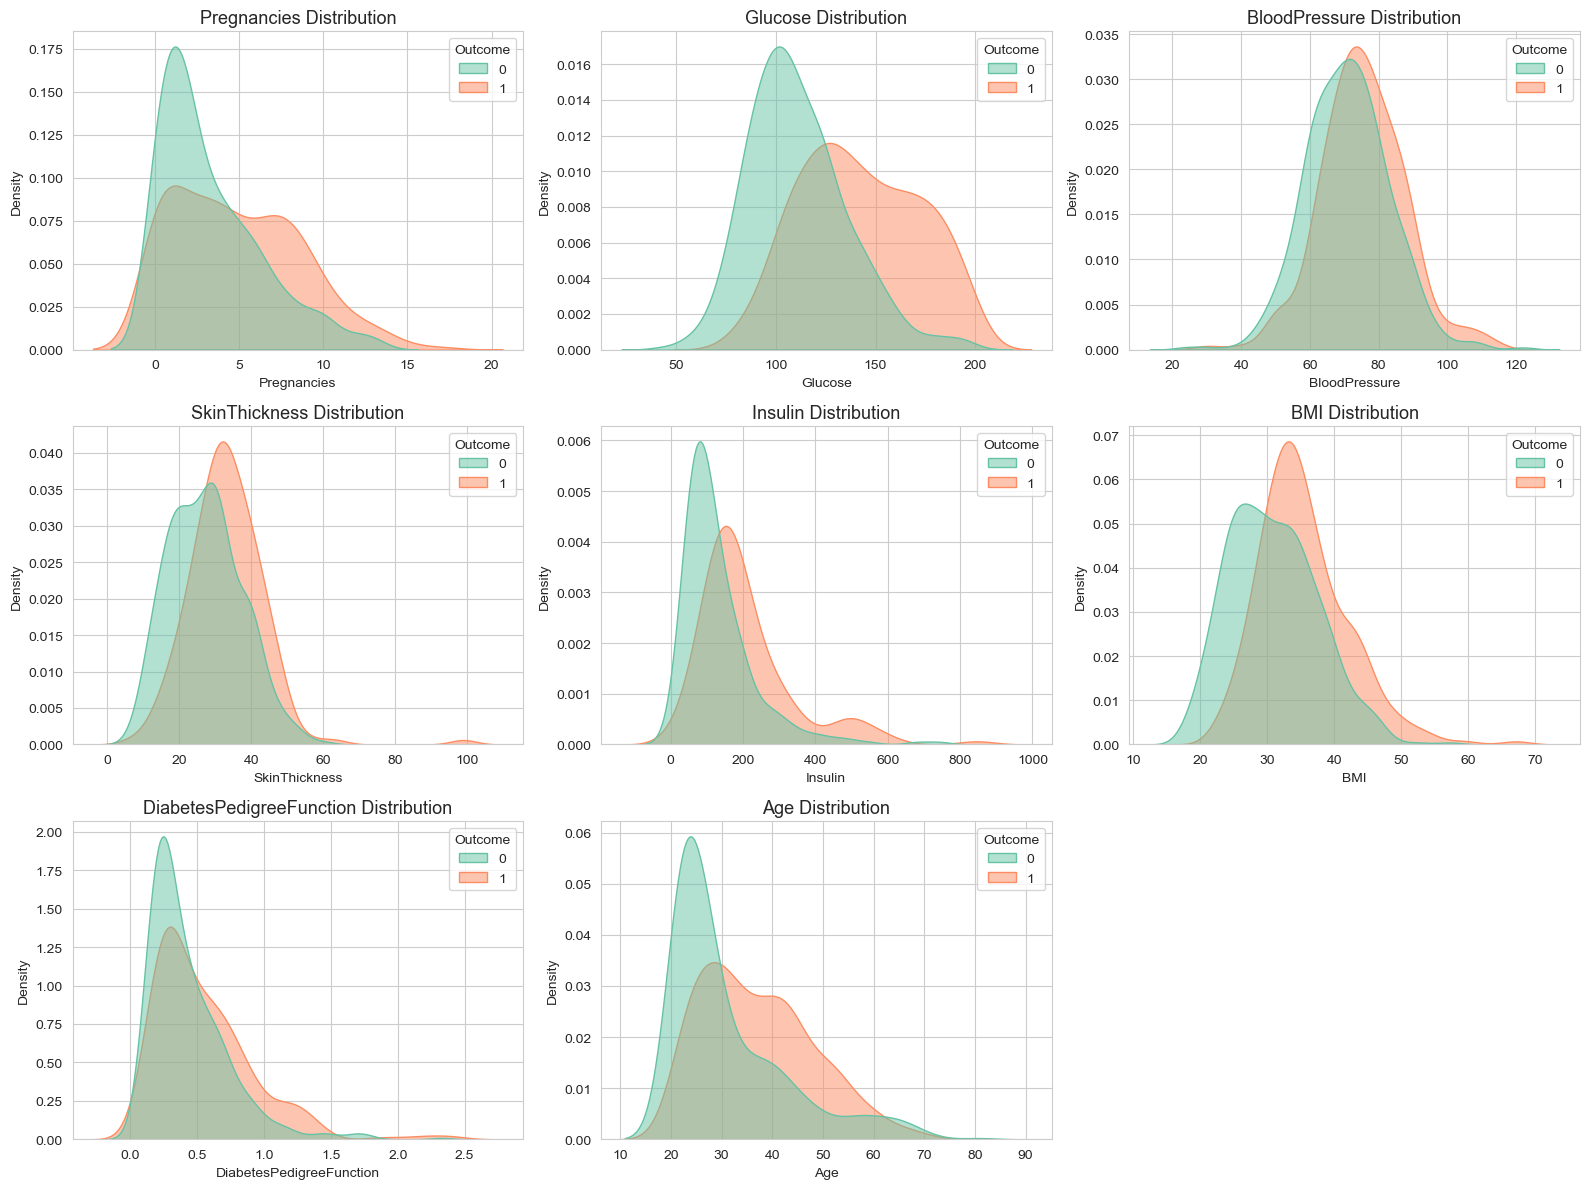

In [11]:
plt.figure(figsize=(16, 12))
sns.set_style("whitegrid")

features= ["Pregnancies", "Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI", "DiabetesPedigreeFunction", "Age"]
for i, col in enumerate(features, 1):
    plt.subplot(3, 3, i)
    sns.kdeplot(data=df, x=col, hue="Outcome", fill=True, common_norm=False, palette="Set2", alpha=0.5)
    plt.title(f"{col} Distribution", fontsize=13)
    plt.xlabel(col)
    plt.ylabel("Density")
    
plt.tight_layout()
plt.show()

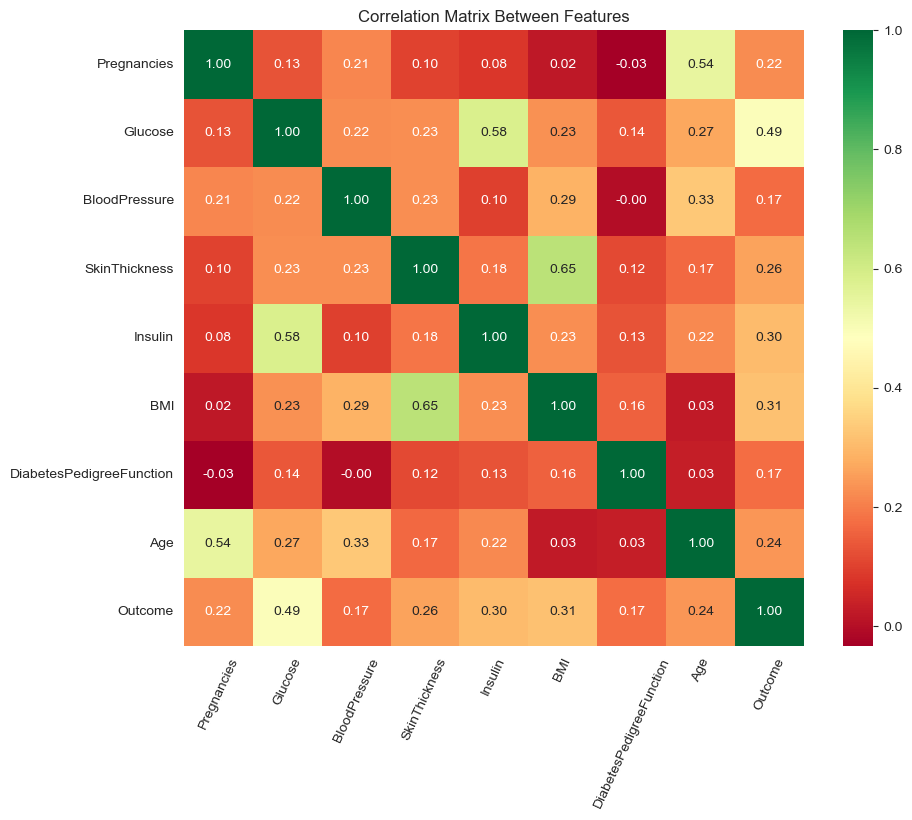

In [12]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f", cmap="RdYlGn")
plt.xticks(rotation=65)
plt.title("Correlation Matrix Between Features")
plt.show()

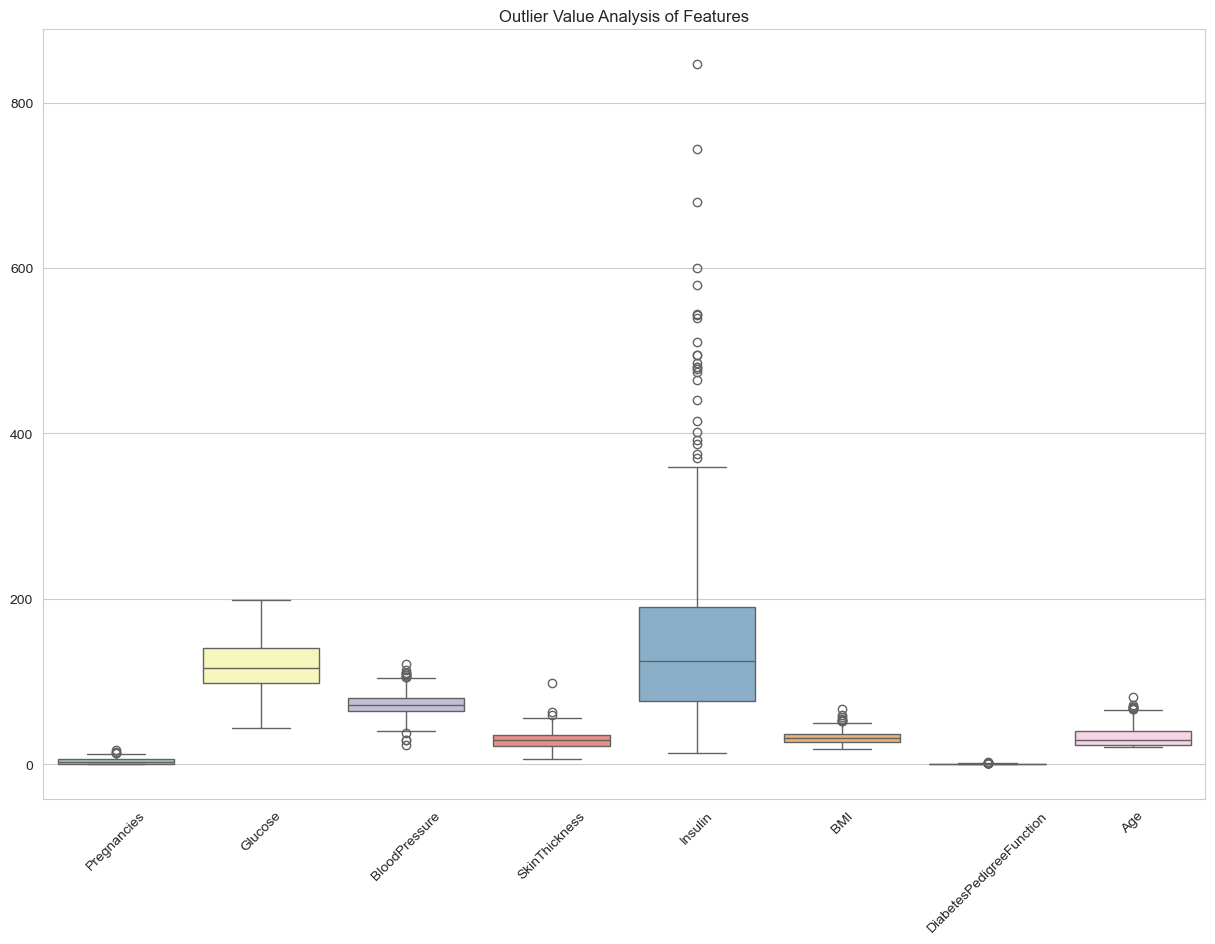

In [13]:
plt.figure(figsize=(15, 10))
sns.boxplot(data=df.drop("Outcome", axis=1), palette="Set3")
plt.xticks(rotation=45)
plt.title("Outlier Value Analysis of Features")
plt.show()

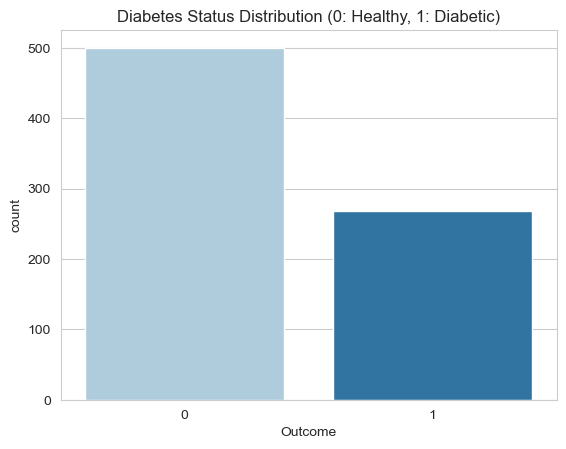

Outcome
0    500
1    268
Name: count, dtype: int64
Outcome
0    65.104167
1    34.895833
Name: proportion, dtype: float64


In [14]:
sns.countplot(x='Outcome', data=df, palette="Paired")
plt.title("Diabetes Status Distribution (0: Healthy, 1: Diabetic)")
plt.show()

print(df["Outcome"].value_counts())
print(df["Outcome"].value_counts(normalize=True) * 100) 

* To examine the relationships between the selected variables and their separation according to the Outcome classes.

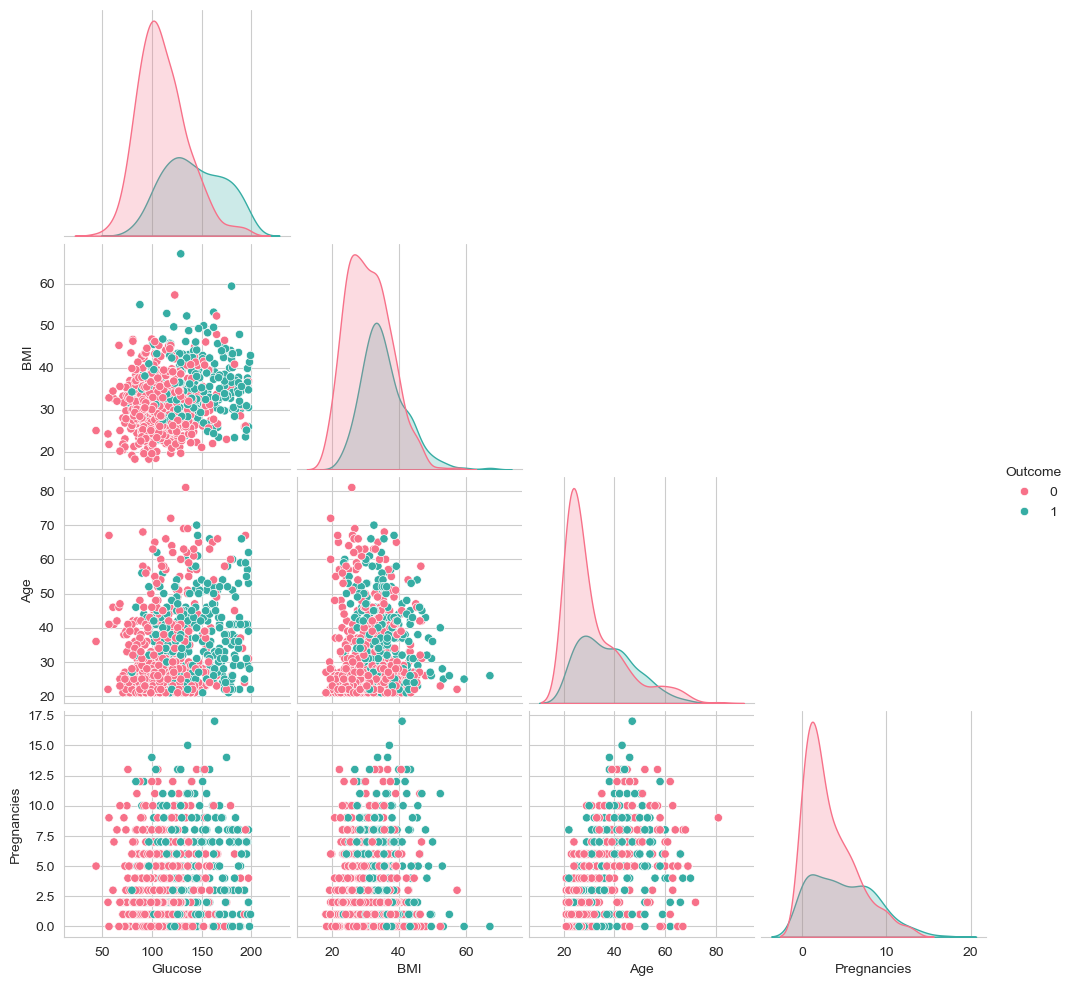

In [15]:
sns.pairplot(df, vars=["Glucose", "BMI", "Age", "Pregnancies"], hue="Outcome", corner=True, palette="husl")
plt.show()


In [16]:
df.groupby("Outcome").mean()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
Outcome,,,,,,,,
0,3.298000,110.643863,70.877339,27.235457,130.287879,30.859674,0.429734,31.190000
1,4.865672,142.319549,75.321429,33.000000,206.846154,35.406767,0.550500,37.067164


In [17]:
df.groupby("Outcome").median()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
Outcome,,,,,,,,
0,2.0,107.0,70.0,27.0,102.5,30.1,0.336,27.0
1,4.0,140.0,74.5,32.0,169.5,34.3,0.449,36.0


In [18]:
df.corr()["Outcome"].sort_values(ascending=False)

Outcome                     1.000000
Glucose                     0.494650
BMI                         0.313680
Insulin                     0.303454
SkinThickness               0.259491
Age                         0.238356
Pregnancies                 0.221898
DiabetesPedigreeFunction    0.173844
BloodPressure               0.170589
Name: Outcome, dtype: float64

In [19]:
X= df.drop("Outcome", axis=1)
y= df["Outcome"]

In [20]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test= train_test_split(X, y, test_size=0.2, random_state=15)

In [21]:
missing_value_features= ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy="median")

X_train[missing_value_features] = imputer.fit_transform(X_train[missing_value_features])
X_test[missing_value_features] = imputer.transform(X_test[missing_value_features])

In [22]:
X_train.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,614.0,3.907166,3.385438,0.000,1.00000,3.0000,6.00000,17.00
Glucose,614.0,121.560261,29.974412,44.000,100.00000,117.0000,139.75000,199.00
BloodPressure,614.0,72.612378,12.165642,24.000,64.00000,72.0000,80.00000,122.00
SkinThickness,614.0,29.040717,8.312217,7.000,25.00000,29.0000,32.00000,63.00
Insulin,614.0,142.477199,80.879330,14.000,125.00000,129.5000,130.00000,680.00
BMI,614.0,32.448208,6.862948,18.200,27.60000,32.3000,36.50000,67.10
DiabetesPedigreeFunction,614.0,0.469948,0.328516,0.084,0.23825,0.3705,0.63075,2.42
Age,614.0,33.285016,11.678337,21.000,24.00000,29.0000,40.00000,81.00


In [23]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.model_selection import GridSearchCV

In [24]:
adaboost_param= {
    "n_estimators": [50, 70, 100, 120, 122, 125, 130],
    "learning_rate": [0.001, 0.01, 0.1, 1.0],
    "algorithm": ["SAMME", "SAMME.R"],
}

In [25]:
grid= GridSearchCV(estimator=AdaBoostClassifier(), param_grid= adaboost_param, cv=5, scoring="f1", verbose=1, n_jobs=-1)

In [26]:
grid.fit(X_train, y_train)

Fitting 5 folds for each of 56 candidates, totalling 280 fits


GridSearchCV(cv=5, estimator=AdaBoostClassifier(), n_jobs=-1,
             param_grid={'algorithm': ['SAMME', 'SAMME.R'],
                         'learning_rate': [0.001, 0.01, 0.1, 1.0],
                         'n_estimators': [50, 70, 100, 120, 122, 125, 130]},
             scoring='f1', verbose=1)

In [27]:
grid.best_params_

{'algorithm': 'SAMME', 'learning_rate': 1.0, 'n_estimators': 122}

In [28]:
ada= AdaBoostClassifier(
    algorithm= 'SAMME',
    learning_rate= 1.0,
    n_estimators= 122,
    random_state=15)

In [29]:
ada.fit(X_train, y_train)

AdaBoostClassifier(algorithm='SAMME', n_estimators=122, random_state=15)

In [30]:
y_pred= ada.predict(X_test)

In [31]:
print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

0.7597402597402597
              precision    recall  f1-score   support

           0       0.84      0.81      0.82       108
           1       0.59      0.65      0.62        46

    accuracy                           0.76       154
   macro avg       0.72      0.73      0.72       154
weighted avg       0.77      0.76      0.76       154

[[87 21]
 [16 30]]


In [32]:
from sklearn.ensemble import RandomForestClassifier

In [33]:
params={
    "n_estimators": [100, 300, 500],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

In [34]:
grid= GridSearchCV(estimator= RandomForestClassifier(random_state=15), param_grid= params, cv=5, scoring= "f1",verbose=1)

In [35]:
grid.fit(X_train, y_train)

Fitting 5 folds for each of 162 candidates, totalling 810 fits


GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=15),
             param_grid={'max_depth': [None, 10, 20],
                         'max_features': ['sqrt', 'log2'],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [100, 300, 500]},
             scoring='f1', verbose=1)

In [36]:
grid.best_params_

{'max_depth': None,
 'max_features': 'log2',
 'min_samples_leaf': 1,
 'min_samples_split': 10,
 'n_estimators': 100}

In [37]:
rfc= RandomForestClassifier(
    n_estimators= 100,
    max_depth= None,
    min_samples_split= 10,
    min_samples_leaf= 1,
    max_features= "log2",
    random_state= 15
)

In [38]:
rfc.fit(X_train, y_train)

RandomForestClassifier(max_features='log2', min_samples_split=10,
                       random_state=15)

In [39]:
y_pred= rfc.predict(X_test)

In [40]:
print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

0.7272727272727273
              precision    recall  f1-score   support

           0       0.82      0.78      0.80       108
           1       0.54      0.61      0.57        46

    accuracy                           0.73       154
   macro avg       0.68      0.69      0.69       154
weighted avg       0.74      0.73      0.73       154

[[84 24]
 [18 28]]


In [41]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

In [42]:
scaler=StandardScaler()

In [43]:
X_train_scaled= scaler.fit_transform(X_train)
X_test_scaled= scaler.transform(X_test)

In [44]:
params= {
    "kernel": ["linear", "poly", "rbf"],
    "C": [0.1, 1.0, 10]
}

In [45]:
grid= GridSearchCV(estimator= SVC(), param_grid= params, cv=5, scoring= "f1", verbose=1)

In [46]:
grid.fit(X_train_scaled,y_train)

Fitting 5 folds for each of 9 candidates, totalling 45 fits


GridSearchCV(cv=5, estimator=SVC(),
             param_grid={'C': [0.1, 1.0, 10],
                         'kernel': ['linear', 'poly', 'rbf']},
             scoring='f1', verbose=1)

In [47]:
grid.best_params_

{'C': 1.0, 'kernel': 'linear'}

In [48]:
svc= SVC(kernel= "linear", C=1.0)

In [49]:
svc.fit(X_train_scaled, y_train)

SVC(kernel='linear')

In [50]:
y_pred= svc.predict(X_test_scaled)

In [51]:
print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

0.7467532467532467
              precision    recall  f1-score   support

           0       0.82      0.82      0.82       108
           1       0.58      0.57      0.57        46

    accuracy                           0.75       154
   macro avg       0.70      0.69      0.70       154
weighted avg       0.75      0.75      0.75       154

[[89 19]
 [20 26]]


In [52]:
from sklearn.linear_model import LogisticRegression

In [53]:
param_log= {
        "penalty":["l1", "l2", "elasticnet"],
        "C": [0.1, 1.0, 10],
        "solver": ["lbfgs", "saga", "liblinear", "newton-cg"]
}

In [54]:
grid= GridSearchCV(estimator= LogisticRegression(), param_grid= param_log, cv=5, scoring= "f1", verbose=1)

In [55]:
grid.fit(X_train_scaled, y_train)

Fitting 5 folds for each of 36 candidates, totalling 180 fits


GridSearchCV(cv=5, estimator=LogisticRegression(),
             param_grid={'C': [0.1, 1.0, 10],
                         'penalty': ['l1', 'l2', 'elasticnet'],
                         'solver': ['lbfgs', 'saga', 'liblinear', 'newton-cg']},
             scoring='f1', verbose=1)

In [56]:
grid.best_params_

{'C': 0.1, 'penalty': 'l1', 'solver': 'liblinear'}

In [57]:
logistic= LogisticRegression(C= 1.0, penalty= 'l1', solver='liblinear')

In [58]:
logistic.fit(X_train_scaled, y_train)

LogisticRegression(penalty='l1', solver='liblinear')

In [59]:
y_pred= logistic.predict(X_test_scaled)

In [60]:
print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

0.7597402597402597
              precision    recall  f1-score   support

           0       0.83      0.83      0.83       108
           1       0.60      0.59      0.59        46

    accuracy                           0.76       154
   macro avg       0.71      0.71      0.71       154
weighted avg       0.76      0.76      0.76       154

[[90 18]
 [19 27]]


In [61]:
from sklearn.neighbors import KNeighborsClassifier

In [62]:
param_knn = {
    "n_neighbors": [3,5,8,10],
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan"]
}

In [63]:
grid= GridSearchCV(estimator= KNeighborsClassifier(), param_grid= param_knn, cv=5, scoring= "f1", verbose=1)

In [64]:
grid.fit(X_train_scaled, y_train)

Fitting 5 folds for each of 16 candidates, totalling 80 fits


GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid={'metric': ['euclidean', 'manhattan'],
                         'n_neighbors': [3, 5, 8, 10],
                         'weights': ['uniform', 'distance']},
             scoring='f1', verbose=1)

In [65]:
grid.best_params_

{'metric': 'euclidean', 'n_neighbors': 10, 'weights': 'distance'}

In [66]:
knn= KNeighborsClassifier(metric= "euclidean", n_neighbors= 10, weights= 'distance')

In [67]:
knn.fit(X_train_scaled, y_train)

KNeighborsClassifier(metric='euclidean', n_neighbors=10, weights='distance')

In [68]:
y_pred= knn.predict(X_test_scaled)

In [69]:
print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

0.7467532467532467
              precision    recall  f1-score   support

           0       0.83      0.81      0.82       108
           1       0.57      0.61      0.59        46

    accuracy                           0.75       154
   macro avg       0.70      0.71      0.70       154
weighted avg       0.75      0.75      0.75       154

[[87 21]
 [18 28]]


In [70]:
from sklearn.tree import DecisionTreeClassifier

In [71]:
params_dt = {
    "max_depth": [2,3,5,8,10],
    "min_samples_split": [2,5,10,20],
    "min_samples_leaf": [1,2,5,10],
    "max_features": ["sqrt", "log2", None],
    "criterion": ["gini", "entropy"]
}

In [72]:
grid= GridSearchCV(estimator= DecisionTreeClassifier(random_state=15), param_grid=params_dt, cv=5, scoring= "f1", verbose=1)

In [73]:
grid.fit(X_train, y_train)

Fitting 5 folds for each of 480 candidates, totalling 2400 fits


GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=15),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [2, 3, 5, 8, 10],
                         'max_features': ['sqrt', 'log2', None],
                         'min_samples_leaf': [1, 2, 5, 10],
                         'min_samples_split': [2, 5, 10, 20]},
             scoring='f1', verbose=1)

In [74]:
grid.best_params_

{'criterion': 'gini',
 'max_depth': 5,
 'max_features': None,
 'min_samples_leaf': 10,
 'min_samples_split': 2}

In [75]:
d_tree= DecisionTreeClassifier(
    criterion= "gini",
    max_depth= 5,
    max_features= None,
    min_samples_leaf= 10,
    min_samples_split= 2,
    random_state=15
)

In [76]:
d_tree.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, min_samples_leaf=10, random_state=15)

In [77]:
y_pred= d_tree.predict(X_test)

In [78]:
print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

0.7337662337662337
              precision    recall  f1-score   support

           0       0.83      0.79      0.81       108
           1       0.55      0.61      0.58        46

    accuracy                           0.73       154
   macro avg       0.69      0.70      0.69       154
weighted avg       0.74      0.73      0.74       154

[[85 23]
 [18 28]]


In [79]:
results = {
    "Model": [
        "AdaBoost",
        "Random Forest",
        "SVC",
        "Logistic Regression",
        "KNN",
        "Decision Tree"
    ],
    "Accuracy": [
        0.7597,
        0.7272,
        0.7467,
        0.7597,
        0.7467,
        0.7337
    ],
    "F1_Class_1": [
        0.62,
        0.57,
        0.57,
        0.59,
        0.59,
        0.58
    ],
    "Recall_Class_1": [
        0.65,
        0.61,
        0.57,
        0.59,
        0.61,
        0.61
    ],
    "Precision_Class_1": [
        0.59,
        0.54,
        0.58,
        0.60,
        0.57,
        0.55
    ]
}

df_results = pd.DataFrame(results)
df_results

,Model,Accuracy,F1_Class_1,Recall_Class_1,Precision_Class_1
0,AdaBoost,0.7597,0.62,0.65,0.59
1,Random Forest,0.7272,0.57,0.61,0.54
2,SVC,0.7467,0.57,0.57,0.58
3,Logistic Regression,0.7597,0.59,0.59,0.60
4,KNN,0.7467,0.59,0.61,0.57
5,Decision Tree,0.7337,0.58,0.61,0.55


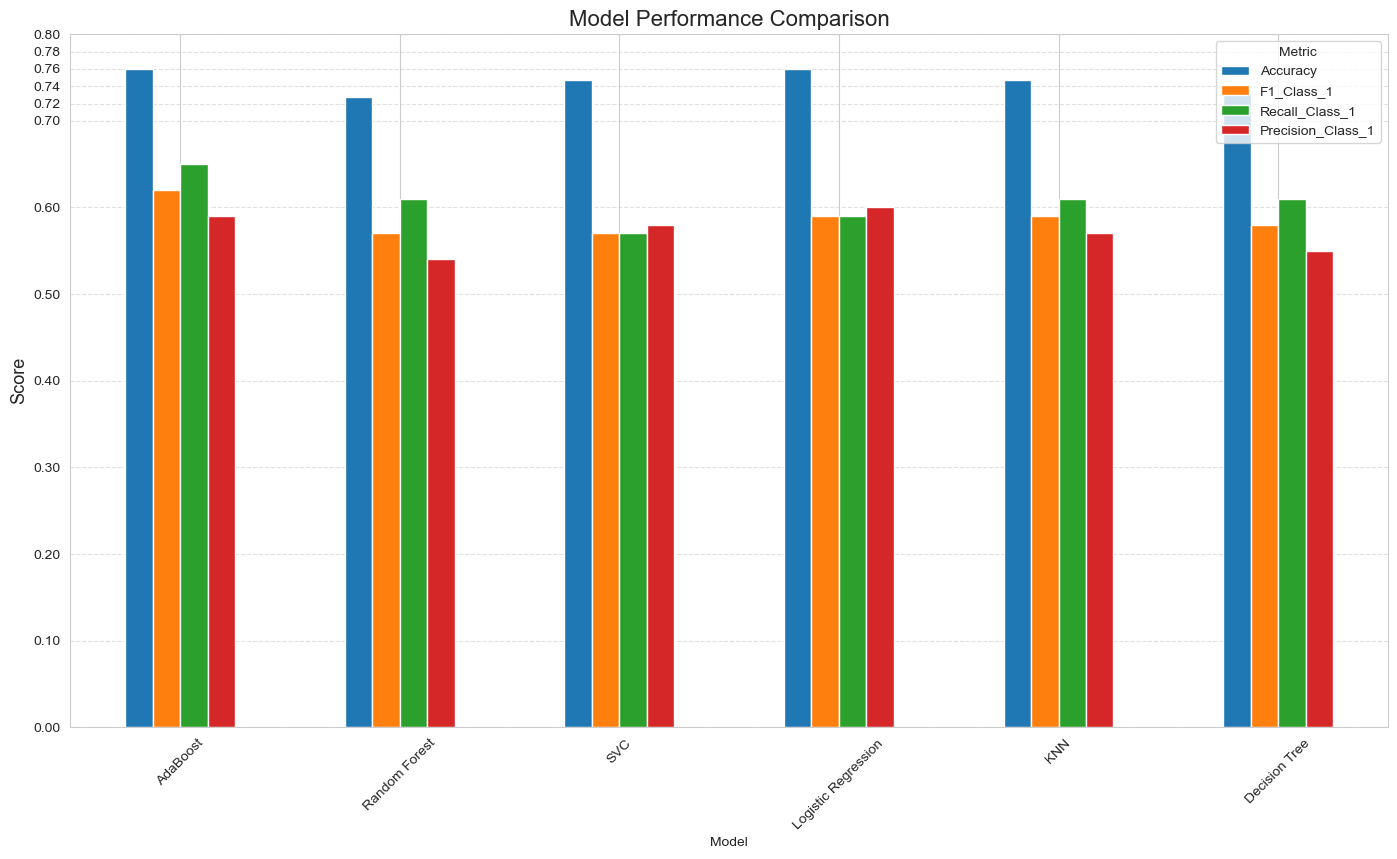

In [80]:
metrics = ["Accuracy", "F1_Class_1", "Recall_Class_1", "Precision_Class_1"]

ax = df_results.set_index("Model")[metrics].plot(
    kind="bar",
    figsize=(17,9)
)

plt.title("Model Performance Comparison", fontsize=16)
plt.ylabel("Score", fontsize=13)
plt.xticks(rotation=45)
plt.legend(title="Metric")

plt.grid(True, axis='y', linestyle='--', alpha=0.6)

low_ticks = np.arange(0.0, 0.70, 0.10)
high_ticks = np.arange(0.70, 0.81, 0.02)

all_ticks = np.concatenate([low_ticks, high_ticks])
plt.yticks(all_ticks)

plt.show()